In [1]:
import pandas as pd
url = 'https://raw.githubusercontent.com/melissazanoni/ids-datasets/refs/heads/main/hotel_foz_historico_forecast.csv'

df = pd.read_csv(url, sep=";")

df.head()


,Data,Dia Semana,Mês,Ano,Total Occ,Arr Rooms,Comp Rooms,House Use,Deduct Indiv,Non-Ded Indiv,Deduct Group,Non-Ded Group,Occ %,Room Revenue (R$),Avg Rate (R$),Dep Rooms,OOO Rooms,Adl & Chl,Arquivo Fonte,Tipo
0,01/03/2026,Sunday,3,2026,135,56,1,1,123,0,12,0,0.8084,56108.87,415.62,107,21,304,06_Marco,Histórico
1,02/03/2026,Monday,3,2026,140,63,0,1,109,0,31,0,0.8537,56300.77,402.15,58,24,295,06_Marco,Histórico
2,03/03/2026,Tuesday,3,2026,111,56,0,2,111,0,0,0,0.6491,42314.27,381.21,85,17,237,06_Marco,Histórico
3,04/03/2026,Wednesday,3,2026,125,61,0,3,112,0,13,0,0.7530,43430.43,347.44,47,22,260,06_Marco,Histórico
4,05/03/2026,Thursday,3,2026,115,50,0,1,102,0,13,0,0.6805,34249.26,297.82,60,19,220,06_Marco,Histórico


Limpeza e Tratamento:

In [2]:
print(df.columns.tolist())

['Data', 'Dia Semana', 'Mês', 'Ano', 'Total Occ', 'Arr Rooms', 'Comp Rooms', 'House Use', 'Deduct Indiv', 'Non-Ded Indiv', 'Deduct Group', 'Non-Ded Group', 'Occ %', 'Room Revenue (R$)', 'Avg Rate (R$)', 'Dep Rooms', 'OOO Rooms', 'Adl & Chl', 'Arquivo Fonte', 'Tipo']


In [3]:
# 1. Remover registros duplicados
print(f"Linhas antes de remover duplicatas: {len(df)}")
df = df.drop_duplicates()
print(f"Linhas após remover duplicatas: {len(df)}")

Linhas antes de remover duplicatas: 243
Linhas após remover duplicatas: 243


In [4]:
# 2. Verificar valores ausentes
print("Valores ausentes por coluna:")
print(df.isnull().sum())

df = df.dropna()

print("\nValores ausentes após limpeza:")
print(df.isnull().sum())

Valores ausentes por coluna:
Data                 0
Dia Semana           0
Mês                  0
Ano                  0
Total Occ            0
Arr Rooms            0
Comp Rooms           0
House Use            0
Deduct Indiv         0
Non-Ded Indiv        0
Deduct Group         0
Non-Ded Group        0
Occ %                0
Room Revenue (R$)    0
Avg Rate (R$)        0
Dep Rooms            0
OOO Rooms            0
Adl & Chl            0
Arquivo Fonte        0
Tipo                 0
dtype: int64

Valores ausentes após limpeza:
Data                 0
Dia Semana           0
Mês                  0
Ano                  0
Total Occ            0
Arr Rooms            0
Comp Rooms           0
House Use            0
Deduct Indiv         0
Non-Ded Indiv        0
Deduct Group         0
Non-Ded Group        0
Occ %                0
Room Revenue (R$)    0
Avg Rate (R$)        0
Dep Rooms            0
OOO Rooms            0
Adl & Chl            0
Arquivo Fonte        0
Tipo                 0
dtype:

In [5]:
# 3. Padronizar nomes das colunas
print("Colunas antes:")
print(df.columns.tolist())

df.columns = df.columns.str.strip().str.lower() #padroniza para letras minusculas
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_") #remove o espaço e troca pra _
df = df.rename(columns={
    "mês": "mes",
    "occ_%": "occ_pct",
    "room_revenue_(r$)": "room_revenue",
    "avg_rate_(r$)": "avg_rate",
    "adl_&_chl": "adl_chl"
})

print("\nColunas depois:")
print(df.columns.tolist())


Colunas antes:
['Data', 'Dia Semana', 'Mês', 'Ano', 'Total Occ', 'Arr Rooms', 'Comp Rooms', 'House Use', 'Deduct Indiv', 'Non-Ded Indiv', 'Deduct Group', 'Non-Ded Group', 'Occ %', 'Room Revenue (R$)', 'Avg Rate (R$)', 'Dep Rooms', 'OOO Rooms', 'Adl & Chl', 'Arquivo Fonte', 'Tipo']

Colunas depois:
['data', 'dia_semana', 'mes', 'ano', 'total_occ', 'arr_rooms', 'comp_rooms', 'house_use', 'deduct_indiv', 'non-ded_indiv', 'deduct_group', 'non-ded_group', 'occ_pct', 'room_revenue', 'avg_rate', 'dep_rooms', 'ooo_rooms', 'adl_chl', 'arquivo_fonte', 'tipo']


In [6]:
# 4. Converter coluna de data para o tipo correto
print("Tipo antes:")
print(df["data"].dtype)

df["data"] = pd.to_datetime(df["data"], dayfirst=True)

# Tipo DEPOIS
print("\nTipo depois:")
print(df["data"].dtype)



Tipo antes:
object

Tipo depois:
datetime64[ns]


Novas variaveis:

In [7]:
# 1. Dia da semana a partir da data
df["dia_semana"] = df["data"].dt.day_name()
print(df["dia_semana"].unique())

['Sunday' 'Monday' 'Tuesday' 'Wednesday' 'Thursday' 'Friday' 'Saturday']


In [8]:
forecast_abril = df[df["mes"] == 4]["occ_pct"].mean()
forecast_maio = df[df["mes"] == 5]["occ_pct"].mean()

print(f"Forecast Abril: {forecast_abril:.2f}%")
print(f"Forecast Maio: {forecast_maio:.2f}%")

Forecast Abril: 0.73%
Forecast Maio: 0.65%


In [9]:
# Forecast de ocupação por mês
forecast = df.groupby("mes")["occ_pct"].mean()
print(forecast)

# Variação percentual entre meses consecutivos
var_ocupacao = forecast.pct_change() * 100

print("Variação de ocupação entre meses (%):")
print(var_ocupacao.round(2))


mes
3    0.789953
4    0.732760
5    0.645887
6    0.506893
7    0.605242
Name: occ_pct, dtype: float64
Variação de ocupação entre meses (%):
mes
3      NaN
4    -7.24
5   -11.86
6   -21.52
7    19.40
Name: occ_pct, dtype: float64


In [10]:
# Calcular variação percentual
var_ocupacao = ((forecast_maio - forecast_abril) / forecast_abril) * 100
print(f"Variação de ocupação: {var_ocupacao:.2f}%")

Variação de ocupação: -11.86%


In [11]:
# Comparar métricas principais para junho (mes=6) e julho (mes=7)
meses_alvo = df[df["mes"].isin([6, 7])]

print("=== Comparativo Junho x Julho ===")
print(meses_alvo.groupby("mes")[["occ_pct", "room_revenue", "avg_rate", "total_occ"]].agg(["mean", "min", "max"]).round(2))

=== Comparativo Junho x Julho ===
    occ_pct             room_revenue                     avg_rate          \
       mean   min   max         mean       min       max     mean     min   
mes                                                                         
6      0.51  0.21  0.96     26928.04   7756.46  68343.04   277.83  158.30   
7      0.61  0.30  0.96     37588.53  17210.86  66810.23   331.82  276.94   

            total_occ           
        max      mean min  max  
mes                             
6    399.67     92.22  39  175  
7    388.43    112.74  57  181  


In [12]:
# Dias com ocupação acima de 90% (previsão otimista)
otimistas = df[df["occ_pct"] >= 0.90]
print(f"Dias com ocupação acima de 90%: {len(otimistas)}")
print(otimistas[["data", "mes", "dia_semana", "occ_pct"]].sort_values("occ_pct", ascending=False).head(10))

# Dias com ocupação abaixo de 40% (previsão pessimista)
pessimistas = df[df["occ_pct"] <= 0.40]
print(f"\nDias com ocupação abaixo de 40%: {len(pessimistas)}")
print(pessimistas[["data", "mes", "dia_semana", "occ_pct"]].sort_values("occ_pct").head(10))

Dias com ocupação acima de 90%: 21
          data  mes dia_semana  occ_pct
100 2026-05-06    5  Wednesday   1.0500
35  2026-04-03    4     Friday   1.0053
34  2026-04-03    4     Friday   0.9893
32  2026-04-02    4   Thursday   0.9832
12  2026-03-13    3     Friday   0.9734
13  2026-03-14    3   Saturday   0.9681
219 2026-07-08    7  Wednesday   0.9628
158 2026-06-04    6   Thursday   0.9607
20  2026-03-21    3   Saturday   0.9519
52  2026-04-12    4     Sunday   0.9494

Dias com ocupação abaixo de 40%: 23
          data  mes dia_semana  occ_pct
209 2026-06-29    6     Monday   0.2074
197 2026-06-23    6    Tuesday   0.2394
195 2026-06-22    6     Monday   0.2500
211 2026-06-30    6    Tuesday   0.2553
205 2026-06-27    6   Saturday   0.2606
203 2026-06-26    6     Friday   0.2660
199 2026-06-24    6  Wednesday   0.2926
169 2026-06-09    6    Tuesday   0.2979
201 2026-06-25    6   Thursday   0.3032
231 2026-07-20    7     Monday   0.3032


Análise de ocupação por mês:

In [24]:
import numpy as np

# Estatísticas descritivas gerais
#print("=== Estatísticas Gerais ===")
#print(df[["occ_pct", "room_revenue", "avg_rate", "total_occ"]].describe())

# Média, mínimo e máximo por mês
#print("\n=== Por Mês ===")
#print(df.groupby("mes")[["occ_pct", "room_revenue", "avg_rate", "total_occ"]].agg(["mean", "min", "max"]).round(2))

(df.groupby("mes")[["occ_pct", "room_revenue", "avg_rate", "total_occ"]]
   .agg(["mean", "min", "max"])
   .round(2)
   .rename(columns={"occ_pct": "Ocupação", "room_revenue": "Receita", "avg_rate": "ADR", "total_occ": "Quartos"})
   .style
   .format({
       ("Ocupação", "mean"): "{:.1%}",
       ("Ocupação", "min"):  "{:.1%}",
       ("Ocupação", "max"):  "{:.1%}",
       ("Receita",  "mean"): "R$ {:,.2f}",
       ("Receita",  "min"):  "R$ {:,.2f}",
       ("Receita",  "max"):  "R$ {:,.2f}",
       ("ADR",      "mean"): "R$ {:,.2f}",
       ("ADR",      "min"):  "R$ {:,.2f}",
       ("ADR",      "max"):  "R$ {:,.2f}",
       ("Quartos",  "mean"): "{:.0f}",
       ("Quartos",  "min"):  "{:.0f}",
       ("Quartos",  "max"):  "{:.0f}",
   })
   .set_caption("Ocupação por Mês")
   .set_table_styles([
       {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold"), ("padding-bottom", "8px")]},
       {"selector": "th", "props": [("background-color", "#4C72B0"), ("color", "white"), ("padding", "8px 12px")]},
       {"selector": "td", "props": [("padding", "6px 12px")]},
       {"selector": "tr:nth-child(even)", "props": [("background-color", "#f5f5f5")]},
   ])
)



Análise Ocupação por dia da semana:

In [25]:
# Média, mínimo e máximo por dia da semana
#print("\n=== Por Dia da Semana ===")
#print(df.groupby("dia_semana")[["occ_pct", "room_revenue", "avg_rate", "total_occ"]].agg(["mean", "min", "max"]).round(2))

(df.groupby("dia_semana")[["occ_pct", "room_revenue", "avg_rate", "total_occ"]]
   .agg(["mean", "min", "max"])
   .reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
   .rename(columns={"occ_pct": "Ocupação", "room_revenue": "Receita", "avg_rate": "ADR", "total_occ": "Quartos"})
   .style
   .format({
       ("Ocupação", "mean"): "{:.1%}",
       ("Ocupação", "min"):  "{:.1%}",
       ("Ocupação", "max"):  "{:.1%}",
       ("Receita",  "mean"): "R$ {:,.2f}",
       ("Receita",  "min"):  "R$ {:,.2f}",
       ("Receita",  "max"):  "R$ {:,.2f}",
       ("ADR",      "mean"): "R$ {:,.2f}",
       ("ADR",      "min"):  "R$ {:,.2f}",
       ("ADR",      "max"):  "R$ {:,.2f}",
       ("Quartos",  "mean"): "{:.0f}",
       ("Quartos",  "min"):  "{:.0f}",
       ("Quartos",  "max"):  "{:.0f}",
   })
   .set_caption("Ocupação por Dia da Semana")
   .set_table_styles([
       {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold"), ("padding-bottom", "8px")]},
       {"selector": "th", "props": [("background-color", "#4C72B0"), ("color", "white"), ("padding", "8px 12px")]},
       {"selector": "td", "props": [("padding", "6px 12px")]},
       {"selector": "tr:nth-child(even)", "props": [("background-color", "#f5f5f5")]},
   ])
)

Análise de quartos por mês:

In [26]:
#print("=== Quartos por Mês ===")
#print(df.groupby("mes")[["arr_rooms", "comp_rooms", "house_use", "dep_rooms", "ooo_rooms"]].agg(["mean", "min", "max"]).round(2))

# Por Mês
(df.groupby("mes")[["arr_rooms", "comp_rooms", "house_use", "dep_rooms", "ooo_rooms"]]
   .agg(["mean", "min", "max"])
   .round(2)
   .rename(columns={"arr_rooms": "Vendidos", "comp_rooms": "Cortesia", "house_use": "Uso Interno", "dep_rooms": "Saídas", "ooo_rooms": "Fora de Ordem"})
   .style
   .format("{:.0f}")
   .set_caption("Quartos por Mês")
   .set_table_styles([
       {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold"), ("padding-bottom", "8px")]},
       {"selector": "th", "props": [("background-color", "#4C72B0"), ("color", "white"), ("padding", "8px 12px")]},
       {"selector": "td", "props": [("padding", "6px 12px")]},
       {"selector": "tr:nth-child(even)", "props": [("background-color", "#f5f5f5")]},
   ])
)


Análise de quartos por dia da semana:

In [27]:
#print("\n=== Quartos por Dia da Semana ===")
#print(df.groupby("dia_semana")[["arr_rooms", "comp_rooms", "house_use", "dep_rooms", "ooo_rooms"]].agg(["mean", "min", "max"]).round(2))

# Por Dia da Semana
(df.groupby("dia_semana")[["arr_rooms", "comp_rooms", "house_use", "dep_rooms", "ooo_rooms"]]
   .agg(["mean", "min", "max"])
   .reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
   .round(2)
   .rename(columns={"arr_rooms": "Vendidos", "comp_rooms": "Cortesia", "house_use": "Uso Interno", "dep_rooms": "Saídas", "ooo_rooms": "Fora de Ordem"})
   .style
   .format("{:.0f}")
   .set_caption("Quartos por Dia da Semana")
   .set_table_styles([
       {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold"), ("padding-bottom", "8px")]},
       {"selector": "th", "props": [("background-color", "#4C72B0"), ("color", "white"), ("padding", "8px 12px")]},
       {"selector": "td", "props": [("padding", "6px 12px")]},
       {"selector": "tr:nth-child(even)", "props": [("background-color", "#f5f5f5")]},
   ])
)

Análise de Receita

In [29]:
# RevPAR (receita por quarto disponível)

#print("\n=== Receita por Mês ===")
#print(df.groupby("mes")[["room_revenue", "avg_rate", "revpar"]].agg(["mean", "min", "max"]).round(2))

df["revpar"] = df["room_revenue"] / (df["arr_rooms"] + df["ooo_rooms"]).replace(0, np.nan)
(df.groupby("mes")[["room_revenue", "avg_rate", "revpar"]]
   .agg(["mean", "min", "max"])
   .rename(columns={"room_revenue": "Receita", "avg_rate": "ADR", "revpar": "RevPAR"})
   .style
   .format({
       ("Receita", "mean"): "R$ {:,.2f}",
       ("Receita", "min"):  "R$ {:,.2f}",
       ("Receita", "max"):  "R$ {:,.2f}",
       ("ADR",     "mean"): "R$ {:,.2f}",
       ("ADR",     "min"):  "R$ {:,.2f}",
       ("ADR",     "max"):  "R$ {:,.2f}",
       ("RevPAR",  "mean"): "R$ {:,.2f}",
       ("RevPAR",  "min"):  "R$ {:,.2f}",
       ("RevPAR",  "max"):  "R$ {:,.2f}",
   })
   .set_caption("Receita por Mês")
   .set_table_styles([
       {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold"), ("padding-bottom", "8px")]},
       {"selector": "th", "props": [("background-color", "#4C72B0"), ("color", "white"), ("padding", "8px 12px")]},
       {"selector": "td", "props": [("padding", "6px 12px")]},
       {"selector": "tr:nth-child(even)", "props": [("background-color", "#f5f5f5")]},
   ])
)

Análise de Receita por semana:

In [30]:
#print("\n=== Receita por Dia da Semana ===")
#rint(df.groupby("dia_semana")[["room_revenue", "avg_rate", "revpar"]].agg(["mean", "min", "max"]).round(2))
(df.groupby("dia_semana")[["room_revenue", "avg_rate", "revpar"]]
   .agg(["mean", "min", "max"])
   .reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
   .rename(columns={"room_revenue": "Receita", "avg_rate": "ADR", "revpar": "RevPAR"})
   .style
   .format({
       ("Receita", "mean"): "R$ {:,.2f}",
       ("Receita", "min"):  "R$ {:,.2f}",
       ("Receita", "max"):  "R$ {:,.2f}",
       ("ADR",     "mean"): "R$ {:,.2f}",
       ("ADR",     "min"):  "R$ {:,.2f}",
       ("ADR",     "max"):  "R$ {:,.2f}",
       ("RevPAR",  "mean"): "R$ {:,.2f}",
       ("RevPAR",  "min"):  "R$ {:,.2f}",
       ("RevPAR",  "max"):  "R$ {:,.2f}",
   })
   .set_caption("Receita por Dia da Semana")
   .set_table_styles([
       {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold"), ("padding-bottom", "8px")]},
       {"selector": "th", "props": [("background-color", "#4C72B0"), ("color", "white"), ("padding", "8px 12px")]},
       {"selector": "td", "props": [("padding", "6px 12px")]},
       {"selector": "tr:nth-child(even)", "props": [("background-color", "#f5f5f5")]},
   ])
)

Análise de Hospedes por mês:

In [31]:
# Hóspedes por quarto ocupado
#print("\n=== Hóspedes por Mês ===")
#print(df.groupby("mes")[["adl_chl", "hospedes_por_quarto"]].agg(["mean", "min", "max"]).round(2))

df["hospedes_por_quarto"] = df["adl_chl"] / df["total_occ"]

(df.groupby("mes")[["adl_chl", "hospedes_por_quarto"]]
   .agg(["mean", "min", "max"])
   .round(2)
   .rename(columns={"adl_chl": "Total Hóspedes", "hospedes_por_quarto": "Hóspedes/Quarto"})
   .style
   .format("{:.0f}")
   .set_caption("Hóspedes por Mês")
   .set_table_styles([
       {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold"), ("padding-bottom", "8px")]},
       {"selector": "th", "props": [("background-color", "#4C72B0"), ("color", "white"), ("padding", "8px 12px")]},
       {"selector": "td", "props": [("padding", "6px 12px")]},
       {"selector": "tr:nth-child(even)", "props": [("background-color", "#f5f5f5")]},
   ])
)


Análise de Hóspedes por semana:

In [32]:
#print("\n=== Hóspedes por Dia da Semana ===")
#print(df.groupby("dia_semana")[["adl_chl", "hospedes_por_quarto"]].agg(["mean", "min", "max"]).round(2))

(df.groupby("dia_semana")[["adl_chl", "hospedes_por_quarto"]]
   .agg(["mean", "min", "max"])
   .reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
   .round(2)
   .rename(columns={"adl_chl": "Total Hóspedes", "hospedes_por_quarto": "Hóspedes/Quarto"})
   .style
   .format("{:.0f}")
   .set_caption("Hóspedes por Dia da Semana")
   .set_table_styles([
       {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold"), ("padding-bottom", "8px")]},
       {"selector": "th", "props": [("background-color", "#4C72B0"), ("color", "white"), ("padding", "8px 12px")]},
       {"selector": "td", "props": [("padding", "6px 12px")]},
       {"selector": "tr:nth-child(even)", "props": [("background-color", "#f5f5f5")]},
   ])
)

Visualização:

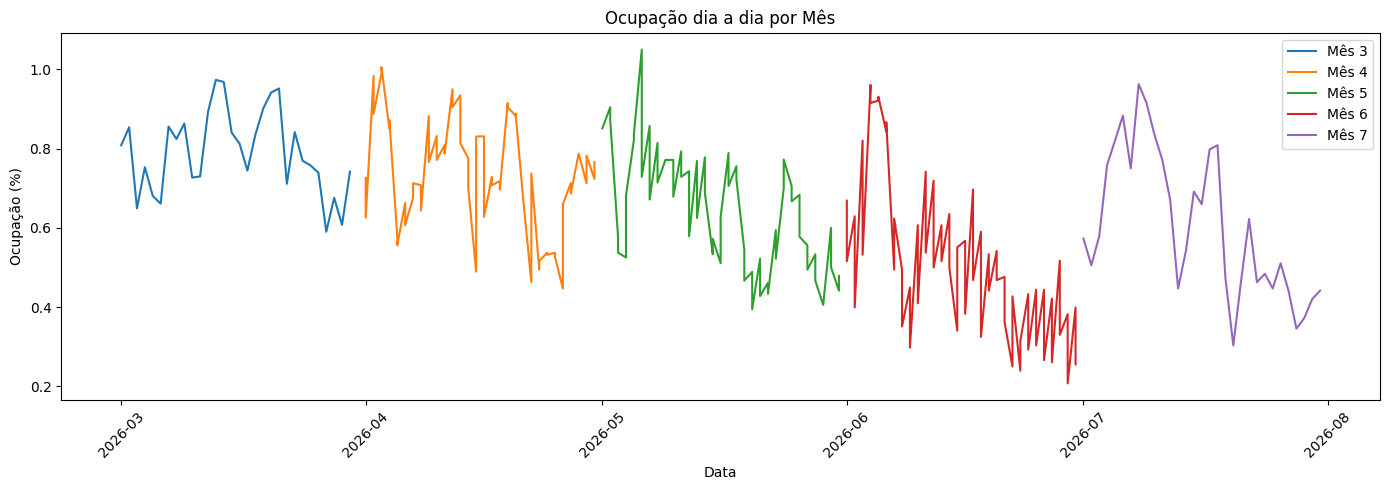

In [21]:
import matplotlib.pyplot as plt

# 5.1 Gráfico de linha - Ocupação dia a dia por mês
plt.figure(figsize=(14, 5))
for mes in df["mes"].unique():
    dados = df[df["mes"] == mes].sort_values("data")
    plt.plot(dados["data"], dados["occ_pct"], label=f"Mês {mes}")

plt.title("Ocupação dia a dia por Mês")
plt.xlabel("Data")
plt.ylabel("Ocupação (%)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

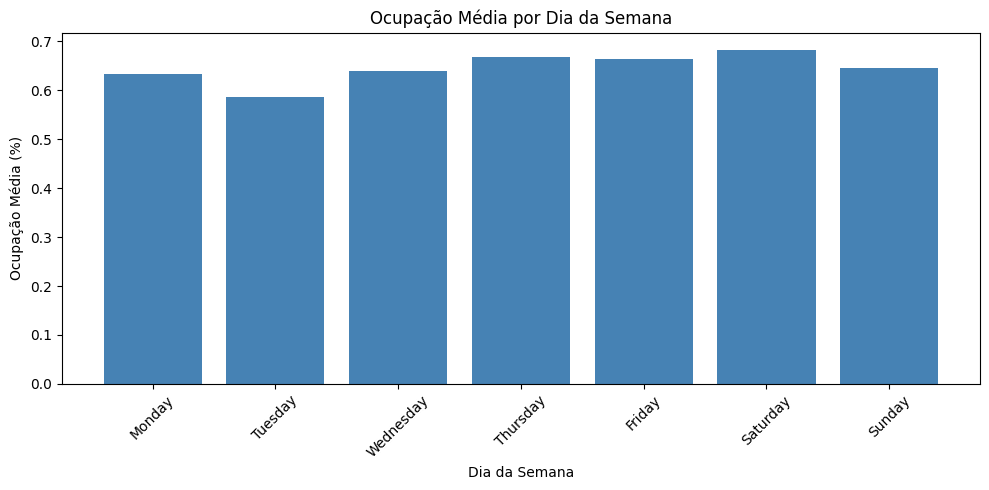

In [22]:
ordem = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
media_dia = df.groupby("dia_semana")["occ_pct"].mean().reindex(ordem)

plt.figure(figsize=(10, 5))
plt.bar(media_dia.index, media_dia.values, color="steelblue")
plt.title("Ocupação Média por Dia da Semana")
plt.xlabel("Dia da Semana")
plt.ylabel("Ocupação Média (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


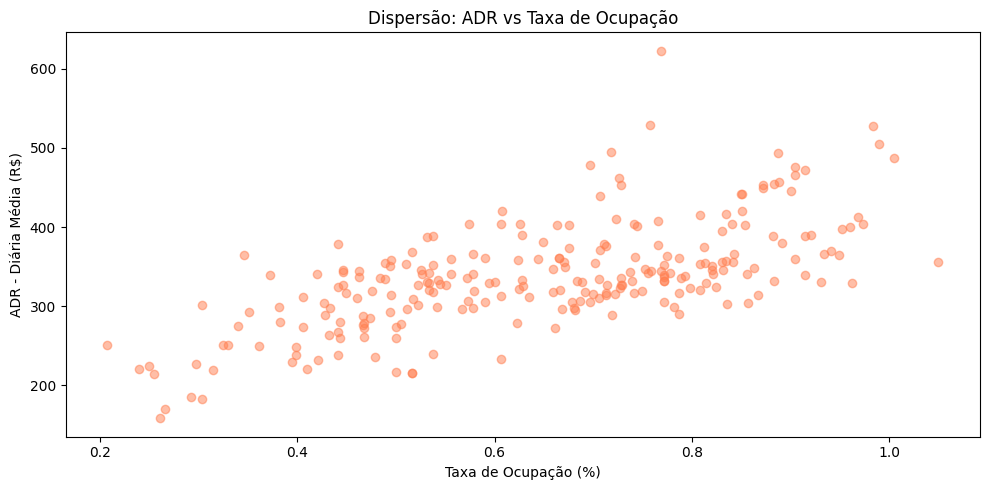

In [23]:
# 5.3 Gráfico de dispersão - ADR vs Taxa de Ocupação
plt.figure(figsize=(10, 5))
plt.scatter(df["occ_pct"], df["avg_rate"], alpha=0.5, color="coral")
plt.title("Dispersão: ADR vs Taxa de Ocupação")
plt.xlabel("Taxa de Ocupação (%)")
plt.ylabel("ADR - Diária Média (R$)")
plt.tight_layout()
plt.show()